In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [4]:
#Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
viridis_colors = cm.viridis (np.linspace(0, 1, 5))
primary_color = viridis_colors [0]
secondary_color = viridis_colors [1]
accent_color = viridis_colors [2]
danger_color = '#800000'
neutral_color = viridis_colors [4]
custom_palette = viridis_colors

In [5]:
df=pd.read_csv('/content/DataCoSupplyChainDataset.csv',encoding='Latin-1')

In [6]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0.0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13915,DEBIT,3,4,49.200001,120.000000,Advance shipping,0,24,Women's Apparel,Philadelphia,...,NaN,502.0,24.0,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0.0,8/18/2015 8:26,Standard Class
13916,DEBIT,6,4,15.000000,120.000000,Late delivery,1,24,Women's Apparel,New York,...,NaN,502.0,24.0,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0.0,10/27/2015 9:34,Standard Class
13917,DEBIT,5,4,-37.790001,89.980003,Late delivery,1,29,Shop By Sport,Washington,...,NaN,627.0,29.0,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0.0,7/3/2017 8:00,Standard Class
13918,DEBIT,4,4,11.890000,71.220001,Shipping on time,0,40,Accessories,Brooklyn,...,NaN,885.0,40.0,NaN,http://images.acmesports.sports/Team+Golf+St.+...,Team Golf St. Louis Cardinals Putter Grip,24.990000,0.0,1/3/2017 11:25,Standard Class


In [7]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [8]:
# Overview
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (13920, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product

In [9]:
#Data Cleaning

columns_to_drop = [
'Product Description',
'Product Image',
'Customer Email',
'Customer Password',
'Customer Fname',
'Customer Lname',
'Customer Street',
'Customer Zipcode',
'Order Zipcode',
'Longitude',
'Latitude',
'Order Item Cardprod Id',
'Order Item Id',
'Order Item Discount',
'Order Item Discount Rate',
'Order Item Product Price',
'Order Item Quantity',
'Order Item Total',
'Category Id',
'Department Id',
'Order Id',
'Order Customer Id',
'Customer Id',
'Product Card Id',
'Product Category Id',
'Benefit per order', # identical to Order Profit Per Order
'Product Status', # have only one value,
'Customer City',
'Order City',
'Order Country',
'Order State',
'Customer State',
'Market']
#dropping columns that are either fully missing, redundant, or have only one value (and thus no variance)
df=df.drop (columns=columns_to_drop)
# removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df [df ['Delivery Status'] != 'Shipping canceled']
#Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
  df[c] = pd.to_datetime(df [c], errors='coerce', dayfirst=False)
# after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values (ascending=False).head(5))

rows, cols: (13300, 20)

Missing values (top 5):
Customer Segment           1
Department Name            1
order date (DateOrders)    1
Order Item Profit Ratio    1
Product Name               1
dtype: int64


In [10]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [11]:
#value counts for categorical columns with low cardinality
for col in df.columns:
  if df[col].nunique()<10:
    print(df[col].value_counts())



Type
DEBIT       6274
TRANSFER    3296
PAYMENT     2053
CASH        1677
Name: count, dtype: int64
Days for shipping (real)
2    3887
4    2343
6    2333
3    2251
5    2242
1     136
0     108
Name: count, dtype: int64
Days for shipment (scheduled)
4    8694
2    2832
1    1530
0     244
Name: count, dtype: int64
Delivery Status
Late delivery       7379
Advance shipping    3492
Shipping on time    2429
Name: count, dtype: int64
Late_delivery_risk
1    7379
0    5921
Name: count, dtype: int64
Customer Country
Puerto Rico    7238
EE. UU.        6062
Name: count, dtype: int64
Customer Segment
Consumer       5995
Corporate      4508
Home Office    2796
Name: count, dtype: int64
Order Status
COMPLETE           5433
PENDING_PAYMENT    1970
PROCESSING         1759
CLOSED             1677
PENDING            1537
ON_HOLD             840
PAYMENT_REVIEW       83
Name: count, dtype: int64
Shipping Mode
Standard Class    8693
Second Class      2832
First Class       1530
Same Day           244
Nam

In [12]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [13]:
#Calculating order processing and time delay
df['time_order_processing']=(df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days
df['delay']=(df['time_order_processing']-df['Days for shipment (scheduled)'])
df['is_delayed']=df['delay']>0
df['order_month']=df['order date (DateOrders)'].dt.month
df['order_day_name']=df['order date (DateOrders)'].dt.day_name()
df['order_hour']=df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),time_order_processing,delay,order_month,order_hour
count,13300.000000,13300.000000,13300.000000,13300.000000,13299,13299.000000,13299.000000,13299.000000,13299.000000,13299,13299.000000,13299.000000,13299.000000,13299.000000
mean,3.702481,3.155639,182.833616,0.554812,2016-06-15 07:32:44.827430656,0.119903,203.771236,21.278886,124.603032,2016-06-19 00:22:59.309722624,3.692383,0.536807,6.532446,11.513347
min,0.000000,0.000000,8.470000,0.000000,2015-01-01 03:51:00,-2.750000,11.290000,-3366.000000,11.290000,2015-01-04 03:51:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,99.580002,0.000000,2015-09-18 23:06:00,0.080000,119.970001,6.720000,50.000000,2015-09-23 04:01:00,2.000000,-1.000000,3.000000,5.000000
50%,4.000000,4.000000,150.000000,1.000000,2016-05-18 09:37:00,0.270000,164.910004,30.209999,59.990002,2016-05-22 23:59:00,4.000000,1.000000,7.000000,12.000000
75%,5.000000,4.000000,251.979996,1.000000,2017-03-04 02:02:00,0.360000,299.950012,63.770000,129.990005,2017-03-07 13:57:00,5.000000,2.000000,9.000000,17.000000
max,6.000000,4.000000,1759.989990,1.000000,2018-01-31 22:56:00,0.500000,1999.989990,684.000000,1999.989990,2018-02-06 04:43:00,6.000000,4.000000,12.000000,23.000000
std,1.530395,1.211514,129.937951,0.497005,NaN,0.466381,144.510412,114.288977,143.217166,NaN,1.551602,1.563965,3.493895,6.932958


In [14]:
df['Profitability_flag']=np.where(df['Order Profit Per Order']>0,'Profit',
                                   np.where(df['Order Profit Per Order']<0,'Loss','Break'))
df['Profitability_flag'].value_counts()

,count
Profitability_flag,
Profit,10726
Loss,2495
Break,79


In [15]:
df['Profitability_flag'].value_counts(normalize=True)

,proportion
Profitability_flag,
Profit,0.806466
Loss,0.187594
Break,0.005940


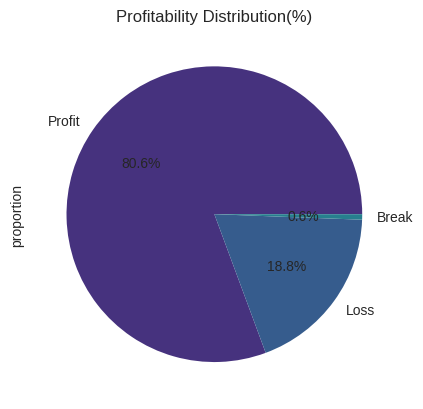

In [16]:
#Visulaization of Profitability flag
profit_counts=df['Profitability_flag'].value_counts(normalize=True)*100
profit_counts.plot(kind='pie',autopct='%1.1f%%',color=[accent_color,danger_color,secondary_color])
plt.title("Profitability Distribution(%)")
plt.show()

In [17]:
def foramt(value):
  if value>=1e6:
    return f'{value/1e6:.1f}M $'
  elif value>=1e3:
    return f'{value/1e3:.1f}M $'
  else:
    return f'{value:.1f} $'
delayed_df=df[df['is_delayed']>0]
metrics={}
metrics['Total Orders']=len(df)
metrics['Late Deliveries']=len(delayed_df)
metrics['90% Delayed(days)']=delayed_df['delay'].quantile(0.9)
metrics['On time Delivery']=(1-float(metrics['Late Deliveries']/metrics['Total Orders']))*100
metrics['Late Delivery%']=float(metrics['Late Deliveries'])/metrics['Total Orders']*100
metrics['Total Profit']=format(df.loc[df['Order Profit Per Order']>0,'Order Profit Per Order'].sum())
metrics['Total Loss due to delays']=format(df.loc[df['delay']>0,'Order Profit Per Order'].sum())
print('\n----Business KPI----\n')
for k,v in metrics.items():
  if isinstance(v,float):
    print(f'{k} : {v:.2f}')
  else:
    print(f'{k} : {v}')



----Business KPI----

Total Orders : 13300
Late Deliveries : 7243
90% Delayed(days) : 3.00
On time Delivery : 45.54
Late Delivery% : 54.46
Total Profit : 576336.559994712
Total Loss due to delays : 143469.680075218


In [18]:
profit_metrics=(
    df.groupby('delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()

)
profit_metrics

,delay,mean_profit,total_profit,order_count
0,-2.0,24.196264,43456.490034,1796
1,-1.0,23.387404,39641.650247,1695
2,0.0,21.996133,56420.080044,2565
3,1.0,21.449400,81486.270153,3799
4,2.0,17.907970,41367.409931,2310
5,3.0,18.728204,9907.219971,529
6,4.0,17.700463,10708.780019,605


In [19]:
delay_distribution=(
    df['delay']
    .value_counts(normalize=True)
    .sort_index()*100
).reset_index()
delay_distribution

,delay,proportion
0,-2.0,13.504775
1,-1.0,12.745319
2,0.0,19.287164
3,1.0,28.566058
4,2.0,17.369727
5,3.0,3.977743
6,4.0,4.549214


,delay,mean_profit,total_profit,order_count
0,-2.0,24.2,43456.5,1796
1,-1.0,23.4,39641.7,1695
2,0.0,22.0,56420.1,2565
3,1.0,21.4,81486.3,3799
4,2.0,17.9,41367.4,2310
5,3.0,18.7,9907.2,529
6,4.0,17.7,10708.8,605


,Delay_Days,Percentage
0,-2.0,13.504775
1,-1.0,12.745319
2,0.0,19.287164
3,1.0,28.566058
4,2.0,17.369727
5,3.0,3.977743
6,4.0,4.549214


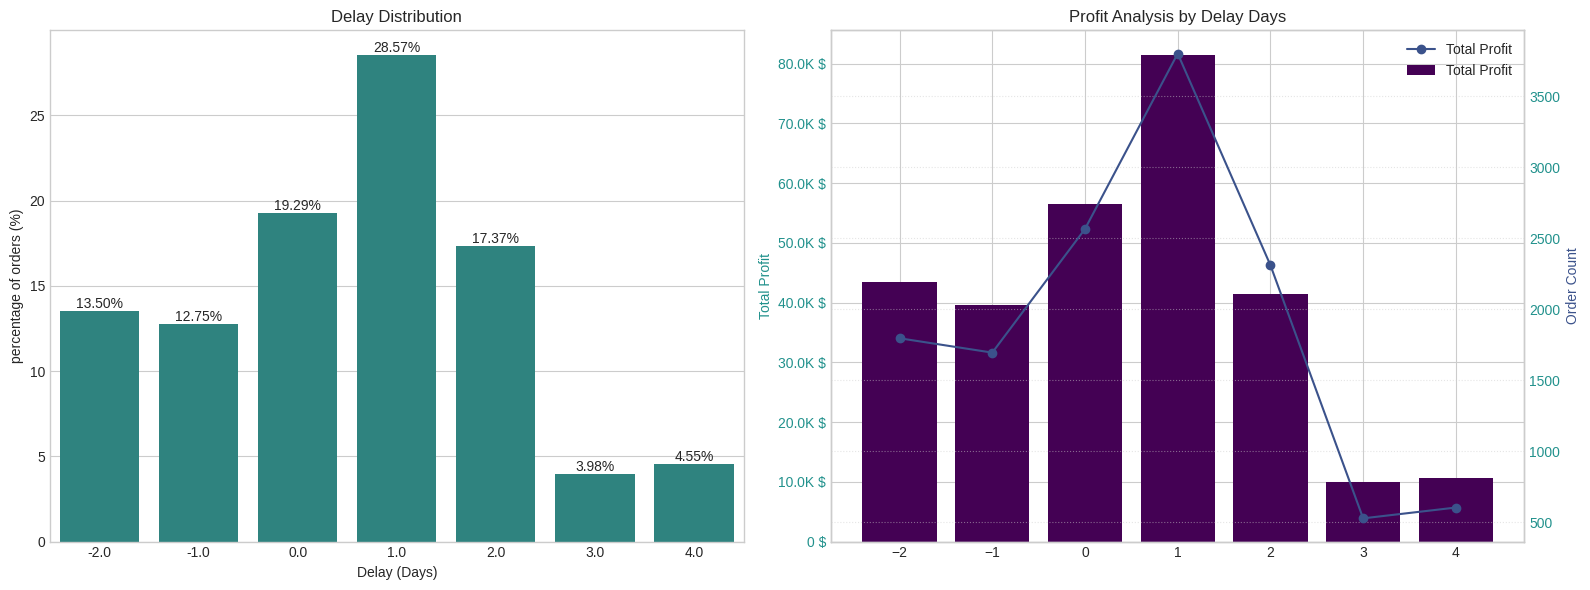

In [20]:
from ipywidgets.widgets.widget_int import Color
delay_distribution.columns=['Delay_Days','Percentage']
display(profit_metrics.round(1))
display(delay_distribution)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))
#First subplot:Delay Distribution
sns.barplot(x='Delay_Days',y='Percentage',data=delay_distribution,color=accent_color,ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (Days)')
ax1.set_ylabel('percentage of orders (%)')
#Percenrage tet on bars
for bar in ax1.patches:
  height=bar.get_height()
  ax1.text(bar.get_x()+bar.get_width()/2,height,f'{height:.2f}%',ha='center',va='bottom')
#second subplot
ax2.set_ylabel("Total Profit",color=accent_color)
ax2.bar(profit_metrics['delay'],profit_metrics['total_profit'],color=primary_color,label="Total Profit")
ax2.tick_params(axis='y',labelcolor=accent_color)

ax3=ax2.twinx()
ax3.set_xlabel("Delay (Days)")
ax3.set_ylabel("Order Count",color=secondary_color)
ax3.plot(profit_metrics['delay'],profit_metrics['order_count'],marker='o',color=secondary_color,label="Total Profit")
ax3.tick_params(axis='y',labelcolor=accent_color)

# Format total profit axis to K $, M $

def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(format_func)
)

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax3.legend(
    lines + lines2,
    labels + labels2,
    loc='upper right'
)

ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

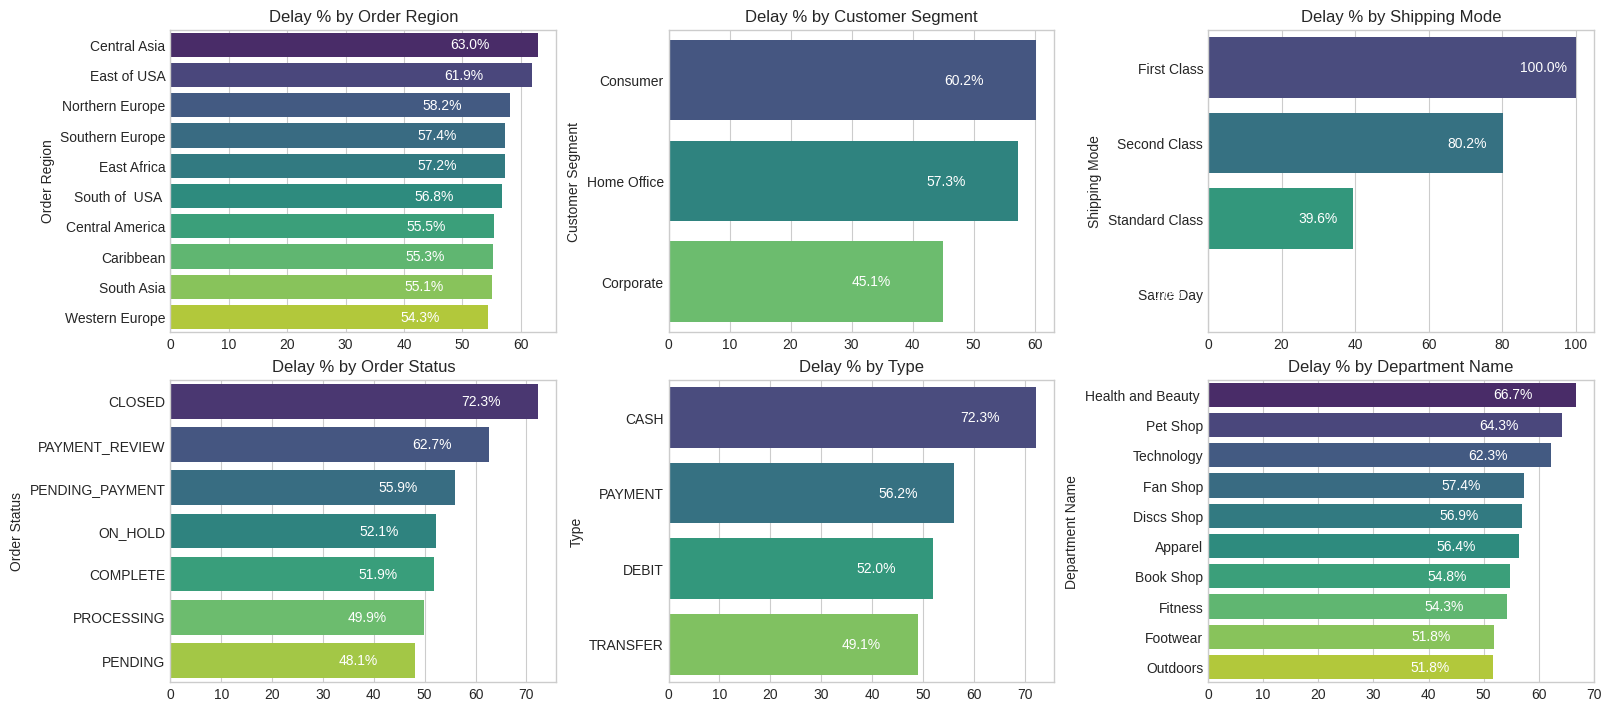

In [21]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('delay', 'count'),
        late_orders=('is_delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (
        cat_df['late_orders'] / cat_df['total_orders'] * 100
    )

    cat_df = cat_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7),
    constrained_layout=True
)

axes = axes.flatten()

for ax, category in zip(axes, categories):

    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

plt.show()

In [22]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'time_order_processing', 'delay', 'is_delayed',
       'order_month', 'order_day_name', 'order_hour', 'Profitability_flag'],
      dtype='object')

In [23]:
def compute_delay_pct_by_category(category):
  cat_df = df.groupby(category).agg(
      total_orders=('delay', 'count'),
      late_orders=('is_delayed', 'sum')
      ).reset_index()
  cat_df ['delay_pct'] = cat_df ['late_orders'] / cat_df['total_orders'] * 100
  cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
  return cat_df



In [24]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
0,Consumer,5995,3611,60.233528
2,Home Office,2796,1601,57.260372
1,Corporate,4508,2031,45.053239


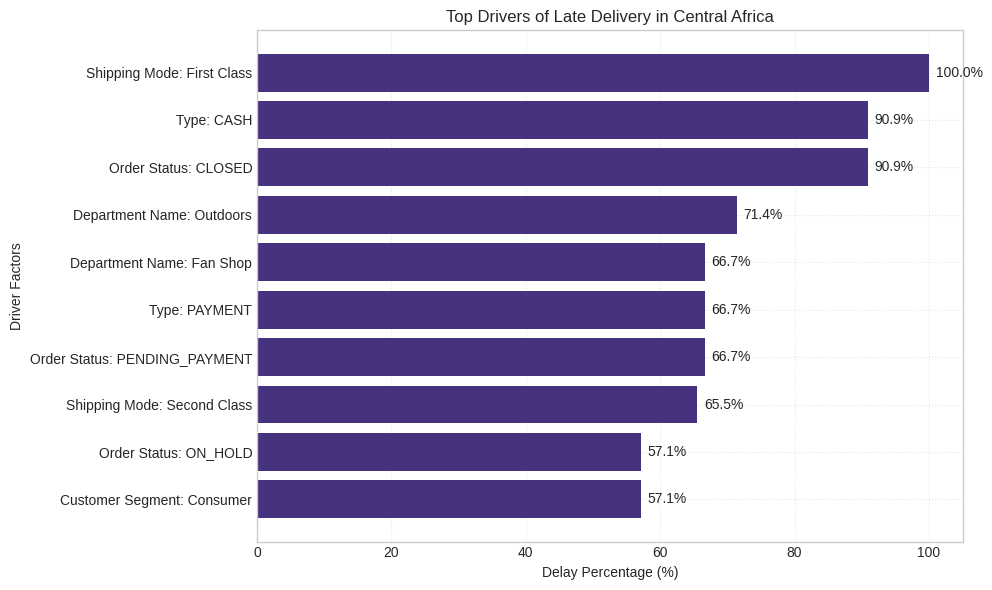

In [25]:
def top_drivers_for_region(region):

    df_region = df[df['Order Region'] == region].copy()

    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]

    all_factors = []

    for factor in drivers:

        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('delay', 'count'),
                late_orders=('is_delayed', 'sum'),
                avg_delay=('delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = (
            temp['late_orders'] / temp['total_orders'] * 100
        )

        temp['Driver'] = factor

        temp['Factor_Level'] = (
            factor + ": " + temp[factor].astype(str)
        )

        all_factors.append(
            temp[
                [
                    'Driver',
                    'Factor_Level',
                    'delay_pct',
                    'avg_delay',
                    'total_orders'
                ]
            ]
        )

    final_df = pd.concat(all_factors, ignore_index=True)

    return final_df


# Get data
region = 'Central Africa'
final_df = top_drivers_for_region(region)

# Top 10 drivers
top_factors = (
    final_df
    .sort_values('delay_pct', ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_factors['Factor_Level'],
    top_factors['delay_pct']
)

plt.xlabel("Delay Percentage (%)")
plt.ylabel("Driver Factors")
plt.title(f"Top Drivers of Late Delivery in {region}")

plt.grid(True, linestyle=':', alpha=0.5)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [26]:
# Delay by Month
delay_by_month = (
    df.groupby('order_month')['is_delayed']
    .mean()
    .reset_index()
)

delay_by_month['delay_pct'] = delay_by_month['is_delayed'] * 100


# Delay by Day of Week
delay_by_day = (
    df.groupby('order_day_name')['is_delayed']
    .mean()
    .reset_index()
)

delay_by_day['delay_pct'] = delay_by_day['is_delayed'] * 100


# Delay by Hour
delay_by_hour = (
    df.groupby('order_hour')['is_delayed']
    .mean()
    .reset_index()
)

delay_by_hour['delay_pct'] = delay_by_hour['is_delayed'] * 100

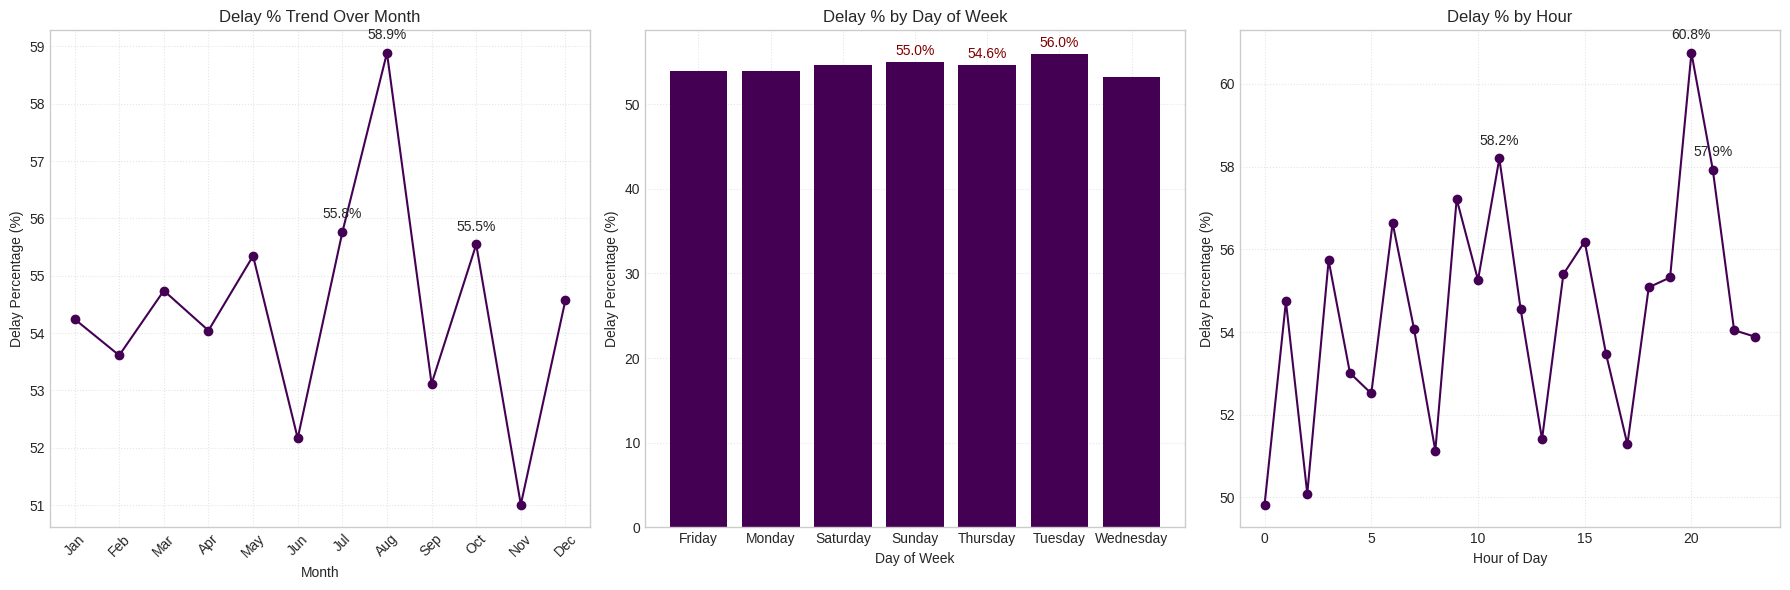

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# ==========================
# Subplot 1: Delay Trend Over Month
# ==========================

ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    color=primary_color
)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest months
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10
    )

# ==========================
# Subplot 2: Delay % by Day
# ==========================

ax2.bar(
    delay_by_day['order_day_name'],
    delay_by_day['delay_pct'],
    color=primary_color
)

ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest days
top3_day = delay_by_day.nlargest(3, 'delay_pct')

for _, row in top3_day.iterrows():
    height = row['delay_pct']

    ax2.text(
        row['order_day_name'],
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color=danger_color
    )

# ==========================
# Subplot 3: Delay % by Hour
# ==========================

ax3.plot(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    marker='o',
    color=primary_color
)

ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest hours
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')

for _, row in top3_hour.iterrows():
    ax3.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_hour'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [28]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'time_order_processing', 'delay', 'is_delayed',
       'order_month', 'order_day_name', 'order_hour', 'Profitability_flag'],
      dtype='object')

In [29]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier

from collections import Counter

from imblearn.over_sampling import SMOTE

In [30]:
X = df[
    [
        'Type',
        'Days for shipment (scheduled)',
        'Category Name',
        'Customer Segment',
        'Department Name',
        'Order Region',
        'Shipping Mode'
    ]
]

y = df['Late_delivery_risk']

In [31]:
# Identify categorical columns
cat_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Categorical columns:", cat_cols)

# Frequency Encoding
for col in cat_cols:

    freq = X[col].value_counts(normalize=True)

    X[f'{col}_freq'] = X[col].map(freq)

# Drop original categorical columns
X_encoded = X.drop(columns=cat_cols)

print("Shape after frequency encoding:", X_encoded.shape)

# Use encoded features for modeling
X = X_encoded

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after frequency encoding: (13300, 7)


In [32]:
y.value_counts()

,count
Late_delivery_risk,
1,7379
0,5921


In [36]:
# Balancing the training data using SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 5903, 0: 4737})
After balancing (train): Counter({1: 5903, 0: 5903})


In [34]:
print(X_train.isnull().sum())

Days for shipment (scheduled)    0
Type_freq                        0
Category Name_freq               0
Customer Segment_freq            1
Department Name_freq             1
Order Region_freq                1
Shipping Mode_freq               1
dtype: int64


In [35]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

def evaluate_model(y_true, y_pred, model_name):

    print(f"\n--- {model_name} ---")

    print("Accuracy :", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall   :", round(recall_score(y_true, y_pred), 2))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))


# Fit the Random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)

rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(
    y_test,
    y_pred_rf_balanced,
    "Random Forest Classifier"
)


--- Random Forest Classifier ---
Accuracy : 0.67
Precision: 0.75
Recall   : 0.59

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.75      0.67      1184
           1       0.75      0.59      0.66      1476

    accuracy                           0.67      2660
   macro avg       0.67      0.67      0.67      2660
weighted avg       0.68      0.67      0.66      2660



In [64]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Save dashboard as HTML
from plotly.offline import plot

# Optional
import warnings
warnings.filterwarnings("ignore")

In [97]:
profit_counts = ( df['Profitability_flag'] .value_counts() )
fig1 = px.pie(
    values=profit_counts.values,
    names=profit_counts.index,
    title="Profitability Distribution",
    color_discrete_sequence=["#22c55e", "#ef4444"]
)

fig1.update_traces(
    hole=0.5,
    textinfo="percent+label"
)

fig1.update_layout(
    title_x=0.5
)

fig1_html = fig1.to_html(full_html=False, include_plotlyjs='cdn')

In [98]:
delay_distribution = (
    df['delay']
    .value_counts(normalize=True)
    .sort_index()*100
)

fig2 = px.bar(
    x=delay_distribution.index,
    y=delay_distribution.values,
    title="Delay Distribution",
    labels={
        'x':'Delay Days',
        'y':'Percentage'
    },
    color=delay_distribution.values,
    color_continuous_scale='Blues'
)

fig2.update_layout(
    title_x=0.5,
    coloraxis_showscale=False
)
fig2_html = fig2.to_html(full_html=False, include_plotlyjs=False)


In [99]:
region_delay = (
    df.groupby('Order Region')
    ['Late_delivery_risk']
    .mean()*100
).sort_values(ascending=False)

fig3 = px.bar(
    region_delay,
    title="Delay Percentage by Region",
    color=region_delay.values,
    color_continuous_scale="Reds"
)

fig3.update_layout(
    title_x=0.5,
    xaxis_title="Region",
    yaxis_title="Delay Percentage (%)",
    coloraxis_showscale=False,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig3.update_traces(
    marker_line_color="black",
    marker_line_width=1,
    texttemplate="%{y:.1f}%",
    textposition="outside"
)

fig3_html = fig3.to_html(full_html=False, include_plotlyjs=False)

In [100]:
segment_delay = (
    df.groupby('Customer Segment')
    ['Late_delivery_risk']
    .mean()*100
)

fig4 = px.bar(
    segment_delay,
    title="Delay Percentage by Customer Segment"
)

fig4.update_traces(
    marker_color="#8b5cf6",
    marker_line_color="#6d28d9",
    marker_line_width=1.5,
    texttemplate="%{y:.1f}%",
    textposition="outside"
)

fig4.update_layout(
    title_x=0.5,
    xaxis_title="Customer Segment",
    yaxis_title="Delay Percentage (%)",
    plot_bgcolor="white",
    paper_bgcolor="white"
)
fig4_html = fig4.to_html(full_html=False, include_plotlyjs=False)


In [101]:
shipping_delay = (
    df.groupby('Shipping Mode')
    ['Late_delivery_risk']
    .mean()*100
)

fig5 = px.bar(
    shipping_delay,
    title="Delay Percentage by Shipping Mode"
)

fig5.update_traces(
    marker_color="#f59e0b",
    marker_line_color="#d97706",
    marker_line_width=1.5,
    texttemplate="%{y:.1f}%",
    textposition="outside"
)

fig5.update_layout(
    title_x=0.5,
    xaxis_title="Shipping Mode",
    yaxis_title="Delay Percentage (%)",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig5_html = fig5.to_html(full_html=False, include_plotlyjs=False)

In [102]:
delay_month = (
    df.groupby('order_month')
    ['Late_delivery_risk']
    .mean()*100
).reset_index()

fig6 = px.line(
    delay_month,
    x='order_month',
    y='Late_delivery_risk',
    markers=True,
    title='Delay Trend By Month'
)

fig6.update_traces(
    line_color='#10b981',
    line_width=4,
    marker=dict(
        size=10,
        color='#059669',
        line=dict(color='white', width=2)
    )
)

fig6.update_layout(
    title_x=0.5,
    xaxis_title='Month',
    yaxis_title='Delay Percentage (%)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified'
)

fig6_html = fig6.to_html(full_html=False, include_plotlyjs=False)

In [103]:
delay_day = (
    df.groupby('order_day_name')
    ['Late_delivery_risk']
    .mean()*100
).reset_index()

fig7 = px.line(
    delay_day,
    x='order_day_name',
    y='Late_delivery_risk',
    markers=True,
    title='Delay Trend By Day'
)

fig7.update_traces(
    line_color='#06b6d4',
    line_width=4,
    marker=dict(
        size=10,
        color='#0891b2',
        line=dict(color='white', width=2)
    )
)

fig7.update_layout(
    title_x=0.5,
    xaxis_title='Day of Week',
    yaxis_title='Delay Percentage (%)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified'
)

fig7_html = fig7.to_html(full_html=False, include_plotlyjs=False)

In [104]:
delay_hour = (
    df.groupby('order_hour')
    ['Late_delivery_risk']
    .mean()*100
).reset_index()
fig8 = px.line(
    delay_hour,
    x='order_hour',
    y='Late_delivery_risk',
    markers=True,
    title='Delay Trend By Hour'
)

fig8.update_traces(
    line_color='#ec4899',
    line_width=4,
    marker=dict(
        size=9,
        color='#db2777',
        line=dict(color='white', width=2)
    )
)

fig8.update_layout(
    title_x=0.5,
    xaxis_title='Order Hour',
    yaxis_title='Delay Percentage (%)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified'
)
fig8_html = fig8.to_html(full_html=False, include_plotlyjs=False)


In [105]:
html = f"""
<!DOCTYPE html>
<html>

<head>

<title>Supply Chain Dashboard</title>

<style>

body {{
    margin:0;
    padding:0;
    font-family:'Segoe UI',sans-serif;
    background:#eef2f7;
    color:#2c3e50;
}}

.container {{
    width:95%;
    margin:auto;
}}

.header {{
    background:#0f172a;
    color:white;
    padding:25px 40px;

    display:flex;
    align-items:center;
    justify-content:flex-start;

    gap:25px;

    border-radius:0 0 20px 20px;
}}

.header img{{

    width:140px;
    height:140px;
    object-fit:cover;
    border-radius:50%;
    border:4px solid white;
    background:white;

}}

.header-text{{
    display:flex;
    flex-direction:column;
    text-align:left;
}}

.header-text h1{{
    margin:0;
    font-size:38px;
    color:white;
}}

.header-text p{{
    margin-top:8px;
    color:#60a5fa;
    font-size:16px;
}}

.chart-box {{
    background:white;
    margin-top:25px;
    border-radius:20px;
    padding:20px;
    box-shadow:0 5px 15px #22c55e;
}}

.chart-title {{
    font-size:24px;
    font-weight:bold;
    margin-bottom:15px;
}}

.conclusion {{
    margin-top:20px;
    padding:15px;
    background:#f8fafc;
    border-left:5px solid #2563eb;
    border-radius:10px;
}}

.footer {{
    text-align:center;
    padding:30px;
    color:#7c3aed;
}}

</style>

</head>

<body>

<div class="header">

      <img src="data:image/jpeg;base64,{encoded_img}" alt="Supply Chain">

    <div>
        <h1>Supply Chain Analytics Dashboard</h1>
        <p>
            Delivery Performance • Profitability • Regional Analysis • Risk Analytics
        </p>
    </div>

</div>

<div class="container">

<div class="chart-box">
<h2 class="chart-title">Profitability Distribution</h2>
{fig1_html}
<div class="conclusion">
<b>Conclusion:</b> Majority of orders are profitable. Loss-making orders should be investigated to improve margins.
</div>
</div>

<div class="chart-box">
<h2 class="chart-title">Delay Distribution</h2>
{fig2_html}
<div class="conclusion">
<b>Conclusion:</b> Delivery delays are concentrated in specific categories and should be prioritized.
</div>
</div>

<div class="chart-box">
<h2 class="chart-title">Delay Percentage by Region</h2>
{fig3_html}
<div class="conclusion">
<b>Conclusion:</b> Certain regions experience significantly higher delays, indicating logistics bottlenecks.
</div>
</div>

<div class="chart-box">
<h2 class="chart-title">Delay Percentage by Customer Segment</h2>
{fig4_html}
<div class="conclusion">
<b>Conclusion:</b> Customer segments show different service levels and delay experiences.
</div>
</div>

<div class="chart-box">
<h2 class="chart-title">Delay Percentage by Shipping Mode</h2>
{fig5_html}
<div class="conclusion">
<b>Conclusion:</b> Shipping mode directly affects delivery success rates.
</div>
</div>

<div class="chart-box">
<h2 class="chart-title">Monthly Delay Trend</h2>
{fig6_html}
<div class="conclusion">
<b>Conclusion:</b> Seasonal fluctuations exist and require operational planning.
</div>
</div>

<div class="chart-box">
<h2 class="chart-title">Day-wise Delay Trend</h2>
{fig7_html}
<div class="conclusion">
<b>Conclusion:</b> Some weekdays consistently show higher delivery risk.
</div>
</div>

<div class="chart-box">
<h2 class="chart-title">Hourly Delay Trend</h2>
{fig8_html}
<div class="conclusion">
<b>Conclusion:</b> Specific order hours show higher probabilities of delayed delivery.
</div>
</div>

<div class="chart-box">
<h2>Executive Summary</h2>

<ul>
<li>Most orders generate positive profit.</li>
<li>Late deliveries remain the primary operational challenge.</li>
<li>Regional disparities indicate logistics inefficiencies.</li>
<li>Shipping mode strongly influences delivery success.</li>
<li>Seasonal trends impact supply chain performance.</li>
<li>Predictive analytics can reduce delivery risks.</li>
</ul>

</div>

</div>

<div class="footer">
Supply Chain Dashboard | Built with Plotly, Python, HTML & CSS
</div>

</body>
</html>
"""

In [106]:
import base64

with open("/content/supply.jpg", "rb") as image_file:
    encoded_img = base64.b64encode(image_file.read()).decode("utf-8")

In [107]:
with open("Supply_Chain_Dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Dashboard saved successfully!")

Dashboard saved successfully!


In [108]:
from google.colab import files

files.download("Supply_Chain_Dashboard.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>